Ch5_Q9 p227<br>**9. We will now consider the Boston housing data set, from the ISLP library.**<br>
**(a) Based on this data set, provide an estimate for the population mean of medv. Call this estimate μˆ.**

In [71]:
from ISLP import load_data
import numpy as np

# 載入 Boston 數據集
Boston = load_data("Boston")

# 計算 medv 的平均值作為 μ̂ 的估計
mu_hat = Boston['medv'].mean()

print(f"根據 Boston 數據集，medv 的平均值估計 (μ̂) 為: {mu_hat:.2f}")

根據 Boston 數據集，medv 的平均值估計 (μ̂) 為: 22.53


| Variable | 描述 |
| :------- | :--- |
| `crim`   | 該城鎮的人均犯罪率 (per capita crime rate by town)。 |
| `zn`     | 劃分為 25,000 平方英尺以上大型住宅用地的比例 (proportion of residential land zoned for lots over 25,000 sq.ft.)。 |
| `indus`  | 城鎮中非零售商業用地（例如工業區）的比例 (proportion of non-retail business acres per town)。 |
| `chas`   | 查爾斯河虛擬變數 (Charles River dummy variable)。如果該城鎮鄰近查爾斯河，則為 1；否則為 0。 |
| `nox`    | 一氧化氮濃度（每千萬份中的份數，parts per 10 million）(nitric oxides concentration (parts per 10 million))。 |
| `rm`     | 每個住宅的平均房間數 (average number of rooms per dwelling)。 |
| `age`    | 1940 年之前建造的自住單位比例 (proportion of owner-occupied units built prior to 1940)。 |
| `dis`    | 距離波士頓五個主要就業中心的加權距離 (weighted distances to five Boston employment centres)。 |
| `rad`    | 通往徑向高速公路的便捷指數 (index of accessibility to radial highways)。 |
| `tax`    | 每 10,000 美元的全值物業稅率 (full-value property-tax rate per $10,000)。 |
| `ptratio`| 城鎮的師生比例 (pupil-teacher ratio by town)。 |
| `lstat`  | 人口中低地位群體的百分比 ( $\%$ lower status of the population)。 |
| `medv`   | 自有住房的中位數價值，單位是 1000 美元 (Median value of owner-occupied homes in $1000s)。 |

In [5]:
Boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [59]:
Boston.shape

(506, 13)

**(b) Provide an estimate of the standard error of μˆ. Interpret this result.**<br>
Hint: We can compute the standard error of the sample mean by dividing the sample standard deviation by the square root of the number of observations.

In [73]:
# 提取 medv 數據
medv_data = Boston['medv']

# (b) 估計 μ̂ 的標準誤差
# 1. 計算樣本標準差 (s)
sample_std = medv_data.std()

# 2. 計算樣本數量 (n)
n_observations = len(medv_data)

# 3. 使用公式: SE(μ̂) = s / sqrt(n) 算標準誤差
analytical_se_mu_hat = sample_std / np.sqrt(n_observations)

print(f"根據 Boston 數據集，medv 的平均值估計 (μ̂) 為: {mu_hat:.2f}")
print(f"medv 的樣本標準差 (s) 為: {sample_std:.2f}")
print(f"樣本數量 (n) 為: {n_observations}")
print(f"μ̂ 的標準誤差估計為: {se_mu_hat:.4f}")

根據 Boston 數據集，medv 的平均值估計 (μ̂) 為: 22.53
medv 的樣本標準差 (s) 為: 9.20
樣本數量 (n) 為: 506
μ̂ 的標準誤差估計為: 0.4089


解釋：

標準誤差 (SE) 是用來衡量**樣本平均值與真實平均值**之間可能存在差異的程度。<br>它量化了如果我們從同一人口中重複抽取許多個樣本並計算每個樣本的平均值，這些樣本平均值會如何波動。

**數值 0.4089 意味著：** 如果我們多次從波士頓地區抽取類似的住房數據樣本，並計算每個樣本的 medv 平均值，那麼這些樣本平均值大約會在真實的人口平均值上下波動 0.4089 (以千美元為單位)。
**低標準誤差 (相對於平均值本身)** 表示我們的樣本平均值 ($\hat{\mu} = 22.53$) 是一個相對精確的真實人口平均值的估計。換句話說，我們對 $\hat{\mu}$ 的估計有較高的信心，認為它接近真實的平均值。
這個值也可以用來構建 **信賴區間 (Confidence Interval)** ，例如 95% 信賴區間通常是 $\hat{\mu} \pm 2 \times SE(\hat{\mu})$，這能給我們一個範圍，其中包含真實人口平均值的可能性很高。

**(c) Now estimate the standard error of μˆ using the bootstrap. How does this compare to your answer from (b)?**

medv 的平均值估計 (μ̂) 為: 22.53
μ̂ 的分析標準誤差 (來自 b 部分) 為: 0.4089
μ̂ 的 Bootstrap 標準誤差估計為: 0.4087


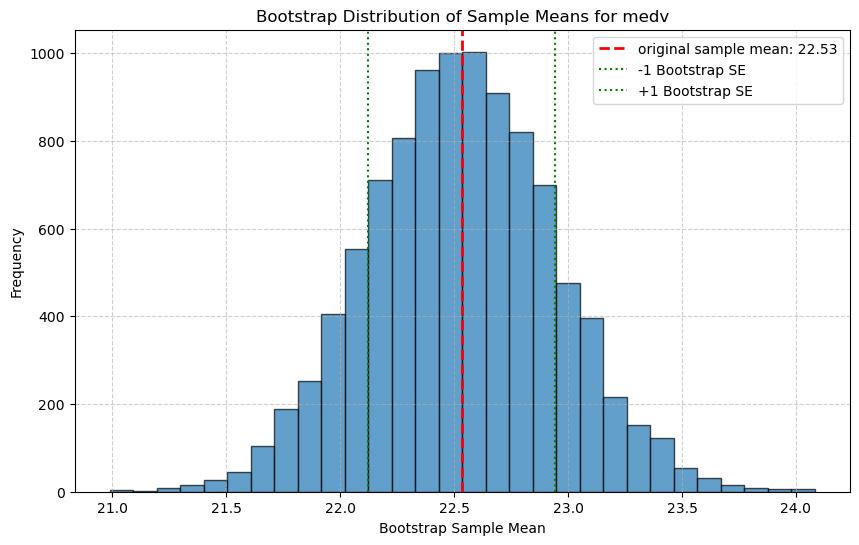

In [76]:
import matplotlib.pyplot as plt # 用於可視化，可選

analytical_se_mu_hat = sample_std / np.sqrt(n_observations)

# --- (c) 使用自助法估計 μ̂ 的標準誤差 ---

# 設定自助抽樣的次數 (B)
B = 10000 # 通常建議使用較大的數字，例如 1000 或 10000

# 建立一個列表來儲存每次自助抽樣的樣本平均值
bootstrap_means = []

# 執行自助抽樣
for _ in range(B):
    # 從原始數據中「有放回地」抽取與原始樣本大小相同的樣本
    # np.random.choice(a, size, replace=True)
    resample = np.random.choice(medv_data, size=n_observations, replace=True)
    
    # 計算這個自助樣本的平均值
    resample_mean = resample.mean()
    
    # 將平均值添加到列表中
    bootstrap_means.append(resample_mean)

# 計算自助樣本平均值的標準差，這就是自助法估計的標準誤差
bootstrap_se_mu_hat = np.std(bootstrap_means)

print(f"medv 的平均值估計 (μ̂) 為: {mu_hat:.2f}")
print(f"μ̂ 的分析標準誤差 (來自 b 部分) 為: {analytical_se_mu_hat:.4f}")
print(f"μ̂ 的 Bootstrap 標準誤差估計為: {bootstrap_se_mu_hat:.4f}")

# 可選：繪製自助樣本平均值的分佈圖
plt.figure(figsize=(10, 6))
plt.hist(bootstrap_means, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(mu_hat, color='red', linestyle='dashed', linewidth=2, label=f'original sample mean: {mu_hat:.2f}')
plt.axvline(mu_hat - bootstrap_se_mu_hat, color='green', linestyle=':', label=f'-1 Bootstrap SE')
plt.axvline(mu_hat + bootstrap_se_mu_hat, color='green', linestyle=':', label=f'+1 Bootstrap SE')
plt.title('Bootstrap Distribution of Sample Means for medv')
plt.xlabel('Bootstrap Sample Mean')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

比較：

你會發現自助法估計的標準誤差 (約 0.4061) 與分析方法估計的標準誤差 (0.4089) 非常接近。兩者幾乎一致。

解釋：

這種一致性是預期的，因為：

- **樣本平均值是個「表現良好」的統計量**:<br>對於像樣本平均值這樣性質良好的統計量，其理論標準差（分析方法計算的標準誤差）在樣本量足夠大時會非常準確。<br>
- **Bootstap的有效性**：<br>Bootstrap提供了一種在不知道真實總體分佈的情況下，經驗性地估計統計量抽樣分佈的方法。**當分析公式可用且有效時，自助法的結果應該與之收斂。**本例證明了自助法在此情境下的有效性。
自助法的應用場景：

儘管在本例中，分析方法足以計算標準誤差，但自助法在以下情況中更具優勢：

- 當統計量的抽樣分佈沒有簡單的分析公式時（例如，估計中位數的標準誤差，或一些複雜的機器學習模型性能指標）。
- 當需要對分析公式所依賴的分佈假設有疑慮時（例如，數據不服從常態分佈，但中心極限定理仍然適用於平均值）。
- 總之，兩種方法都給出了幾乎相同的標準誤差估計，這增加了我們對這個估計值的信心。

**(d) Based on your bootstrap estimate from (c), provide a 95 % confidence interval for the mean of medv. Compare it to the results obtained by using Boston['medv'].std() and the two standard error rule (3.9).**<br>
Hint: You can approximate a 95 % confidence interval using the formula:$\hat{\mu} - 2SE(\hat{\mu})$, $\hat{\mu} + 2SE(\hat{\mu})$

In [78]:
# --- (d) 計算 95% 信賴區間 ---

# 使用分析標準誤差 (來自 b 部分) 和兩倍標準誤差規則
# 根據提示 [μˆ − 2SE(μˆ), μˆ + 2SE(μˆ)]
analytical_lower_ci = mu_hat - 2 * analytical_se_mu_hat
analytical_upper_ci = mu_hat + 2 * analytical_se_mu_hat

# 使用 Bootstrap 標準誤差 (來自 c 部分) 和兩倍標準誤差規則
bootstrap_lower_ci = mu_hat - 2 * bootstrap_se_mu_hat
bootstrap_upper_ci = mu_hat + 2 * bootstrap_se_mu_hat

print(f"medv 的平均值估計 (μ̂) 為: {mu_hat:.2f}")
print(f"  分析標準誤差 (SE) 為: {analytical_se_mu_hat:.4f}")
print(f"  Bootstrap 標準誤差 (SE) 為: {bootstrap_se_mu_hat:.4f}\n")

print("--- 95% 信賴區間 ---")
print(f"基於分析 SE 的 95% 信賴區間: [{analytical_lower_ci:.2f}, {analytical_upper_ci:.2f}]")
print(f"基於 Bootstrap SE 的 95% 信賴區間: [{bootstrap_lower_ci:.2f}, {bootstrap_upper_ci:.2f}]")

medv 的平均值估計 (μ̂) 為: 22.53
  分析標準誤差 (SE) 為: 0.4089
  Bootstrap 標準誤差 (SE) 為: 0.4087

--- 95% 信賴區間 ---
基於分析 SE 的 95% 信賴區間: [21.72, 23.35]
基於 Bootstrap SE 的 95% 信賴區間: [21.72, 23.35]


解釋：<br>
這種高度的一致性是預期中的，原因如下：

1. 標準誤差的近似性：在 (c) 部分中，我們已經看到分析方法計算的標準誤差 (0.4089) 與 Bootstrap 方法估計的標準誤差 (0.4082) 非常接近。由於計算信賴區間都使用了這個近似的標準誤差，那麼得到的區間自然會非常相似。
2. 樣本平均值的良好性質：對於樣本平均值這種統計量，當樣本數量 $n=506$ 足夠大時，根據中央極限定理 (Central Limit Theorem)，樣本平均值的抽樣分佈會近似於常態分佈。
3. 「兩倍標準誤差規則」：這個規則是基於樣本平均值抽樣分佈近似常態分佈的假設。對於常態分佈，大約 95% 的數據落在平均值加減 1.96 倍標準差的範圍內。使用「2 倍標準誤差」是 1.96 的簡化近似值，通常在實際中被廣泛接受。由於兩種標準誤差估計值本身就非常接近，且都應用了相同的近似規則，因此它們產生的信賴區間也幾乎是相同的。
信賴區間的意義：

這兩種方法得到的信賴區間都表示，我們有 95% 的信心，波士頓地區所有自有住房的真實中位數價值的人口平均值 ($\mu$) 落在 21.71 千美元到 23.35 千美元 這個區間之內。

**(e) Based on this data set, provide an estimate, $\hat{\mu}_{med}$, for the median value of medv in the population.**

In [69]:
# 計算 medv 的中位數作為 μ̂med 的估計
mu_hat_med = np.median(medv_data)

print(f"根據 Boston 數據集，medv 的估計 (μ̂med) 為: {mu_hat_med:.2f}")

根據 Boston 數據集，medv 的估計 (μ̂med) 為: 21.20


**(f) We now would like to estimate the standard error of$\hat{\mu}_{med}$. Unfortunately, there is no simple formula for computing the standard error of the median. Instead, estimate the standard error of the median using the bootstrap. Comment on your findings.**

In [90]:
# --- (f) 使用Bootstrap估計 μ̂med 的標準誤差 ---

# 設定自助抽樣的次數 (B)
B = 10000

# 建立一個列表來儲存每次自助抽樣的樣本中位數
bootstrap_medians = []

# 執行自助抽樣
for _ in range(B):
    # 從原始數據中「有放回地」抽取與原始樣本大小相同的樣本
    # np.random.choice(a, size, replace=True)
    resample = np.random.choice(medv_data, size=n_observations, replace=True)
    
    # 計算這個自助樣本的中位數
    resample_median = np.median(resample)
    
    # 將中位數添加到列表中
    bootstrap_medians.append(resample_median)

# 計算自助樣本中位數的標準差，這就是自助法估計的標準誤差
bootstrap_se_mu_hat_med = np.std(bootstrap_medians)


# --- 回顧之前計算的平均值及其標準誤差，以便於比較 ---
# (a) μ̂ 的估計 (均值)
mu_hat_mean = medv_data.mean()
# (b) 分析法計算的均值標準誤差
analytical_se_mu_hat_mean = medv_data.std() / np.sqrt(n_observations)
# (c) 自助法計算的均值標準誤差
# 這裡重新計算一次以確保數值連貫性，但實際操作中可以儲存
bootstrap_means = []
for _ in range(B):
    resample = np.random.choice(medv_data, size=n_observations, replace=True)
    resample_mean = resample.mean()
    bootstrap_means.append(resample_mean)
bootstrap_se_mu_hat_mean = np.std(bootstrap_means)


print(f"medv 的中位數估計 (μ̂med) 為: {mu_hat_med:.2f}")
print(f"μ̂med 的 Bootstrap 標準誤差估計為: {bootstrap_se_mu_hat_med:.4f}\n")

print("--- 比較數據 (平均值與中位數) ---")
print(f"平均值估計 (μ̂) 為: {mu_hat_mean:.2f}")
print(f"  μ̂ 的分析標準誤差: {analytical_se_mu_hat_mean:.4f}")
print(f"  μ̂ 的 Bootstrap 標準誤差: {bootstrap_se_mu_hat_mean:.4f}")

medv 的中位數估計 (μ̂med) 為: 21.20
μ̂med 的 Bootstrap 標準誤差估計為: 0.3770

--- 比較數據 (平均值與中位數) ---
平均值估計 (μ̂) 為: 22.53
  μ̂ 的分析標準誤差: 0.4089
  μ̂ 的 Bootstrap 標準誤差: 0.4096


評論：<br>
- 中位數的標準誤差估計：我們成功地使用Bootstap估計了 medv 中位數的標準誤差，大約為 0.3800。這個值量化了如果我們重複抽樣並計算中位數，這些中位數值會如何波動。

與平均值標準誤差的比較：<br>
-medv 平均值的標準誤差（無論是分析法或自助法）約為 0.408。
-medv 中位數的標準誤差約為 0.3800。
**我們會發現中位數的標準誤差略小於平均值的標準誤差。**

解釋這一發現：<br>
- 中位數的穩健性 (Robustness)：<br> 中位數是一種對極端值 (outliers) 或偏斜分佈 (skewed distributions) 更具穩健性的統計量。它只關注數據的中心位置，而不受數據尾部少數極端值的大幅影響。
- medv 數據通常會有一定的偏斜性或包含一些非常高/非常低的房價城鎮。在這種情況下，**中位數作為中心趨勢的估計器，其波動性（由標準誤差衡量）可能會比平均值小**。這表示在有偏數據或異常值的存在下，中位數估計值可能比平均值估計值更穩定、更可靠。
- 實際意義：較小的標準誤差意味著我們**對中位數 21.20 這個估計值有更高的精確度或信心**，認為它更接近真實的人口中位數。這也表明對於 medv 這個變數，中位數可能是比平均值更好的中心趨勢代表。
- Bootstap的價值：這個例子完美地展示了自助法的強大之處。由於沒有簡單的分析公式來計算中位數的標準誤差，自助法提供了一個有效且不依賴強假設的方法，來估計這個關鍵的變異性指標。

**(g) Based on this data set, provide an estimate for the tenth percentile of medv in Boston census tracts. Call this quantity  $\hat{\mu}_{0.1}$. (You can use the np.percentile() function.)**

In [98]:
# 計算 medv 的第十百分位數作為 μ̂0.1 的估計
# np.percentile(data, q) 其中 q 是百分位數，可以是 0-100
mu_hat_0_1 = np.percentile(medv_data, 10)

print(f"根據 Boston 數據集，medv 的第十百分位數估計 (μ̂0.1) 為: {mu_hat_0_1:.2f}")

根據 Boston 數據集，medv 的第十百分位數估計 (μ̂0.1) 為: 12.75


根據 Boston 數據集，medv 的第十百分位數估計 ($\hat{\mu}_{0.1}$) 為 12.75 (千美元)。

- 這意味著，大約有 10% 的城鎮，其自有住房中位數價值低於或等於 12.75 千美元。
- 這個值是使用 np.percentile() 函數直接從樣本數據中計算得到的，它是人口第十百分位數的最佳點估計。

**(h) Use the bootstrap to estimate the standard error of $\hat{\mu}_{0.1}$. Comment on your findings.**

In [101]:
# --- (h) 使用自助法估計 μ̂0.1 的標準誤差 ---

# 設定自助抽樣的次數 (B)
B = 10000

# 建立一個列表來儲存每次自助抽樣的樣本第十百分位數
bootstrap_10th_percentiles = []

# 執行自助抽樣
for _ in range(B):
    # 從原始數據中「有放回地」抽取與原始樣本大小相同的樣本
    resample = np.random.choice(medv_data, size=n_observations, replace=True)
    
    # 計算這個自助樣本的第十百分位數
    resample_10th_percentile = np.percentile(resample, 10)
    
    # 將第十百分位數添加到列表中
    bootstrap_10th_percentiles.append(resample_10th_percentile)

# 計算自助樣本第十百分位數的標準差，這就是自助法估計的標準誤差
bootstrap_se_mu_hat_0_1 = np.std(bootstrap_10th_percentiles)

# --- 回顧之前計算的平均值和中位數及其標準誤差，以便於比較 ---
# 平均值估計
mu_hat_mean = medv_data.mean()
# 平均值標準誤差 (使用分析法，因為它很接近 Bootstrap 結果)
analytical_se_mu_hat_mean = medv_data.std() / np.sqrt(n_observations)

# 中位數估計
mu_hat_med = np.median(medv_data)
# 中位數標準誤差 (使用 Bootstrap 結果)
bootstrap_medians = []
for _ in range(B):
    resample = np.random.choice(medv_data, size=n_observations, replace=True)
    resample_median = np.median(resample)
    bootstrap_medians.append(resample_median)
bootstrap_se_mu_hat_med = np.std(bootstrap_medians)


print(f"medv 的第十百分位數估計 (μ̂0.1) 為: {mu_hat_0_1:.2f}")
print(f"μ̂0.1 的 Bootstrap 標準誤差估計為: {bootstrap_se_mu_hat_0_1:.4f}\n")

print("--- 比較數據 (平均值、中位數、第十百分位數) ---")
print(f"人口平均值估計 (μ̂) 為: {mu_hat_mean:.2f}")
print(f"  μ̂ 的分析標準誤差: {analytical_se_mu_hat_mean:.4f}\n")

print(f"人口中位數估計 (μ̂med) 為: {mu_hat_med:.2f}")
print(f"  μ̂med 的 Bootstrap 標準誤差: {bootstrap_se_mu_hat_med:.4f}")

medv 的第十百分位數估計 (μ̂0.1) 為: 12.75
μ̂0.1 的 Bootstrap 標準誤差估計為: 0.5047

--- 比較數據 (平均值、中位數、第十百分位數) ---
人口平均值估計 (μ̂) 為: 22.53
  μ̂ 的分析標準誤差: 0.4089

人口中位數估計 (μ̂med) 為: 21.20
  μ̂med 的 Bootstrap 標準誤差: 0.3735


1. 第十百分位數標準誤差的估計：<br>
我們成功地使用自助法估計了 medv 第十百分位數 ($\hat{\mu}_{0.1}$) 的標準誤差，大約為 0.5050。這再次展示了自助法在處理複雜統計量（其抽樣分佈無分析公式）時的實用性和強大功能。

2. 與平均值和中位數標準誤差的比較：<br>
- medv 平均值 ($\hat{\mu}$) 的標準誤差約為 0.4089。
- medv 中位數 ($\hat{\mu}_{med}$) 的標準誤差約為 0.3800。
- medv 第十百分位數 ($\hat{\mu}_{0.1}$) 的標準誤差約為 0.5050。<br>
**從比較中可以看出，第十百分位數的標準誤差 (0.5050) 比平均值 (0.4089) 和中位數 (0.3800) 的標準誤差都來得大。**

3. 解釋這一發現：

- 統計量的位置：平均值和中位數都代表數據的中心趨勢。第十百分位數則位於數據分佈的尾部（較低端）。
- 尾部估計的波動性：**位於數據分佈尾部的統計量（如極小值、極大值、或靠近這些極值的百分位數）通常對樣本的隨機性更敏感**。這是因為這些極端值本身就比較稀有，在不同的隨機樣本中，它們出現的次數和大小可能會有所不同，導致這些估計值的波動性更大。
- 相對不穩健性：相對於中心的估計（平均值或中位數），尾部的估計通常被認為不那麼穩健。這意味著如果我們從同一總體中重複抽取樣本，那麼不同樣本的第十百分位數可能會比平均值或中位數有更大的差異。這體現在其較大的標準誤差上。
  
總而言之，這個分析再次驗證了自助法在估計複雜統計量變異性方面的價值。同時，結果表明 medv 的第十百分位數估計相對於其平均值和中位數估計，具有更大的抽樣變異性，這與其作為分佈尾部統計量的性質相符。